## Task - 6

## Visulization of metrics and graph

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [2]:
data = pd.read_csv('clear_bank.csv')
data

,Unnamed: 0,age,marital,education,default,balance,housing,loan,day,duration,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,0,30,1,0,0,1787,0,0,19,79,...,0,0,0,0,0,1,0,0,0,1
1,1,33,1,1,0,4789,1,1,11,220,...,0,0,0,1,0,0,0,0,0,0
2,2,35,2,2,0,1350,1,0,16,185,...,0,0,0,0,0,0,0,0,0,0
3,3,30,1,2,0,1476,1,1,3,199,...,0,1,0,0,0,0,0,0,0,1
4,4,59,1,1,0,0,1,0,5,226,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,4516,33,1,1,0,-333,1,0,30,329,...,1,0,0,0,0,0,0,0,0,1
4517,4517,57,1,2,1,-3313,1,1,9,153,...,0,0,0,1,0,0,0,0,0,1
4518,4518,57,1,1,0,295,0,0,19,151,...,0,0,0,0,0,0,0,0,0,1
4519,4519,28,1,1,0,1137,0,0,6,129,...,0,0,0,0,0,0,0,1,0,0


## Train_test_split

In [3]:
X = data.drop(columns = ['y'])
y = data['y']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Train model

In [8]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [11]:
svm = SVC(kernel = 'rbf')
svm.fit(X_train,y_train)

SVC()

In [25]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=5000)

In [26]:
models = ['Random Forest', 'SVM', 'Logistic Regression']
accuracies = [
    accuracy_score(y_test, rf.predict(X_test)),
    accuracy_score(y_test, svm.predict(X_test)),
    accuracy_score(y_test, lr.predict(X_test))]

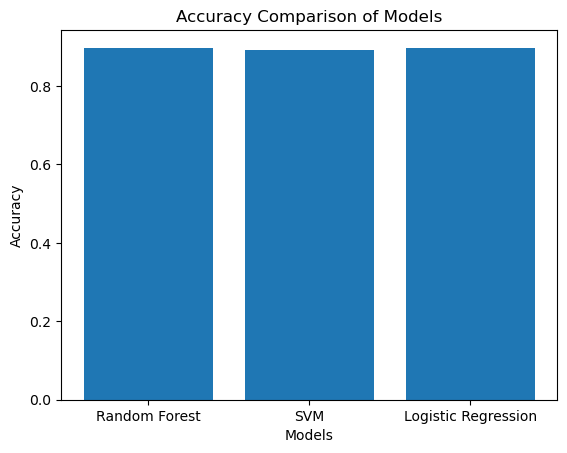

In [27]:
plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Models")
plt.show()

## cross validation fold graph 

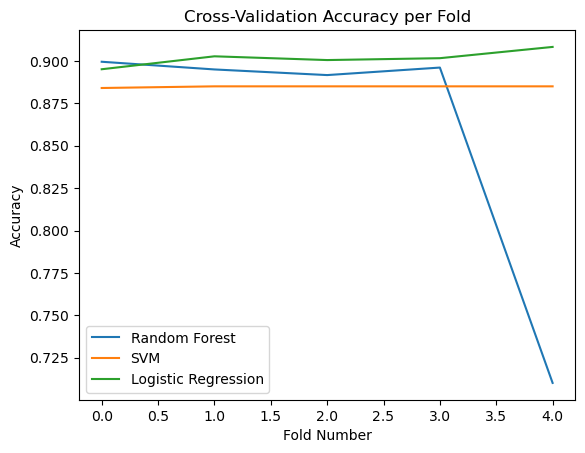

In [30]:
plt.figure()
plt.plot(rf_cv, label="Random Forest")
plt.plot(svm_cv, label="SVM")
plt.plot(lr_cv, label="Logistic Regression")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy per Fold")
plt.legend()
plt.show()

## Scaling and modeling

In [40]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

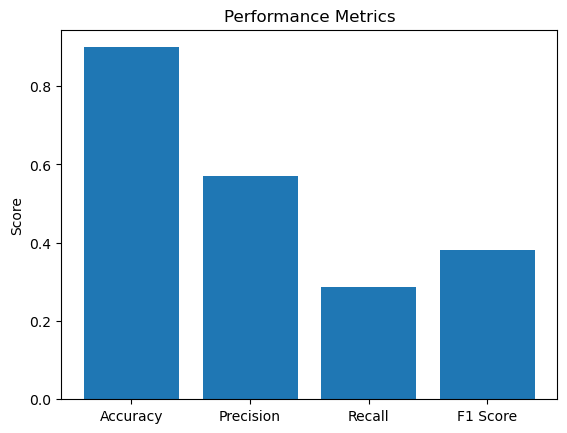

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

plt.bar(metrics, values)
plt.ylabel("Score")
plt.title("Performance Metrics")
plt.show()

In [37]:
## confusion Metrics

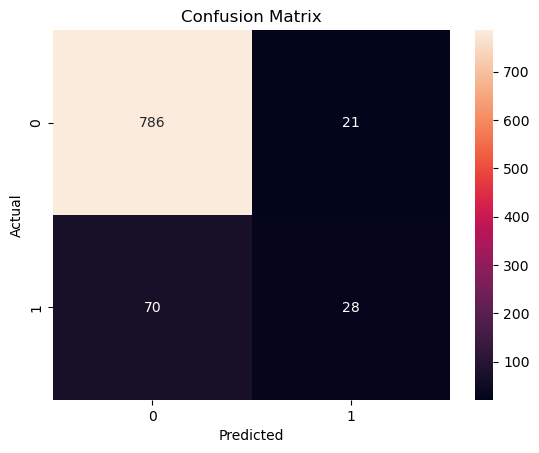

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## ROC curve

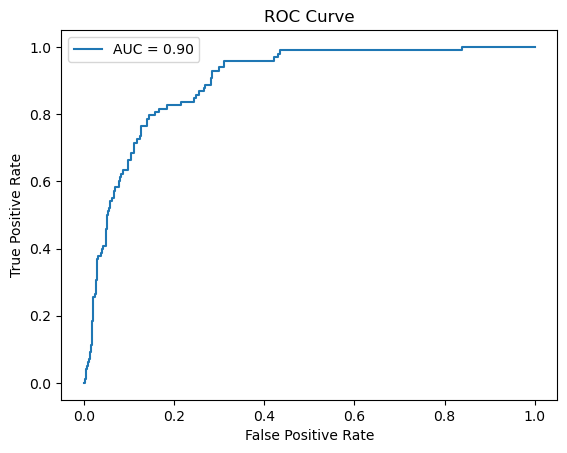

In [42]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## prediction probability Distribution

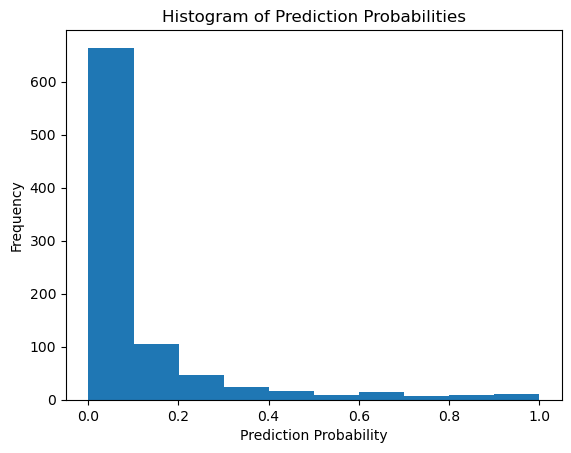

In [43]:
plt.figure()
plt.hist(y_prob, bins=10)
plt.xlabel("Prediction Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Probabilities")
plt.show()


## Boxplot feature distribution

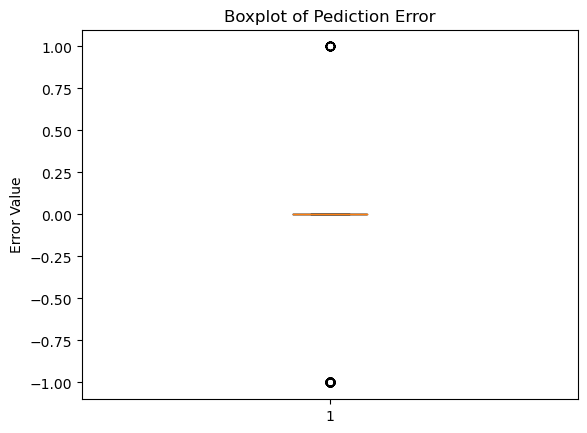

In [48]:
errors = y_pred - y_test

plt.figure()
plt.boxplot(errors)
plt.ylabel("Error Value")
plt.title("Boxplot of Pediction Error")
plt.show()
